# Import Libraries

In [1]:
import sys, os

# Add path to import
sys.path.append(os.path.abspath(".."))

In [2]:
from src.forecasting.utils.libraries_data_handling import pd, np
from src.forecasting.utils.libraries_others import re, os, time, Enum, Optional, gc, pickle, json, ast
from src.forecasting.utils.libraries_plotting import plt
from src.forecasting.utils.libraries_modelling import torch, concatenate, TimeSeries, Scaler, TFTModel, plot_contour, plot_optimization_history, plot_param_importances, QuantileRegression, TFTExplainer
from src.forecasting.utils.memory import cleanup
from src.forecasting.utils.data_split import dataframe_train_valid_test_split
from src.forecasting.utils.scale_timeseries_per_component import scale_Y_timeseries_per_component, scale_X_timeseries_per_component
from src.forecasting.constants.columns import col_decode, col_encode
from src.forecasting.constants.enums import ColumnGroup, PeriodList
from src.forecasting.models.tft_build import tft_build
from src.forecasting.models.evaluate_cv_timeseries import evaluate_cv_timeseries
from src.forecasting.models.evaluate_test_timeseries import evaluate_test_timeseries
from src.forecasting.models.tft_store_to_excel import tft_inference_store_to_excel
from src.forecasting.models.empty_worst_model import empty_worst_model

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
/home/jovyan/work/3012010008/env_3012010008/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Set Up

In [3]:
GPU = False
# Initialize internal precision of matrix multiplication
if torch.cuda.is_available():
    torch.set_float32_matmul_precision('high')
    torch.manual_seed(42)
    GPU = True

# Make dir to store results
work_dir  = '../models/checkpoint_inference_tft/'
os.makedirs(work_dir, exist_ok=True)

# Setting number after coma to max 5 digits
np.set_printoptions(suppress=True, precision=5)

# Function

In [4]:
def get_targets(df, target_cols=None):
    if target_cols is None:
        target_cols = ['y1', 'y2', 'y3', 'y4', 'y5', 'y6']
    available = [col for col in target_cols if col in df.columns]
    return df[available].astype('float32')

def get_features(df, target_cols=None):
    if target_cols is None:
        target_cols = ['y1','y2','y3','y4','y5','y6']
    available_targets = [col for col in target_cols if col in df.columns]
    return df.drop(columns=available_targets).astype('float32')

def load_dataset_for_inference(
    dataset_type : str,
    valid_size   : float,
    drop_cols    : bool,
    test_size    : float = 0.1,
):
    # ========================= LOAD DATA ========================= #
    # Load actual data
    df_actual = pd.read_csv('../data/processed/past_covariates_noOutliers_5.csv').drop(
        columns=['x1','x2','x3','x4_zero', 'x4_nonzero','x5','x6','x7_sin', 'x7_cos','x8_zero', 'x8_nonzero'])

    # Load past dataset
    if dataset_type == 'sqrt_NoOzon_5':
        prenorm_type = 'sqrt'
        df_past = pd.read_csv(
            '../data/processed/past_covariates_sqrt_transform_NoOzon_5.csv'
        )
        df_actual = df_actual.drop(columns=['y6'])

    elif dataset_type == 'log1p_NoOzon_5':
        prenorm_type = 'log1p'
        df_past = pd.read_csv(
            '../data/processed/past_covariates_log_transform_NoOzon_5.csv'
        )
        df_actual = df_actual.drop(columns=['y6'])

    elif dataset_type == 'no_outliers_noOzon_5':
        prenorm_type = None
        df_past = pd.read_csv(
            '../data/processed/past_covariates_noOutliers_NoOzon_5.csv'
        )
        df_actual = df_actual.drop(columns=['y6'])

    else:
        raise ValueError(f'Unknown dataset_type: {dataset_type}')

    # Load future dataset
    df_future = pd.read_csv('../data/processed/future_covariates_optimized.csv')

    # ========================= DATA PREPROCESSING ========================= #
    # Set index
    for name, df in zip(
        ['past','future','actual'],
        [df_past, df_future, df_actual]
    ):
        df['t'] = pd.to_datetime(df['t'])
        df.set_index('t', inplace=True)
        df.sort_index(inplace=True)
        df.asfreq('h')
    
    # Clip future dataset
    df_future_more = df_future.copy()
    df_future      = df_future.iloc[:len(df_past)]
    df_future_more = df_future_more.iloc[len(df_past):]

    ## ========================= LOAD CORRELATION RESULTS ========================= ##
    # Load correlation results
    results_r = pd.read_csv('../data/processed/correlation_scores.csv')

    # Take very low correlation level (0.00 - 0.199) to drop
    dropped_covariates = results_r[results_r['Correlation'] <= 0.2]['Feature'].to_list()

    # Encode drop colomns name
    dropped_covariates = [col_encode[feature] for feature in dropped_covariates]

    # Drop covariates columns
    if drop_cols == True:
        df_past = df_past.drop(columns=['x4_zero', 'x4_nonzero', 'x5', 'x7_sin', 'x7_cos'])

    ## ========================= DATA SPLIT ========================= ##
    # Split dataset into Y and X
    Y        = get_targets(df_past)
    X_past   = get_features(df_past)
    X_future = df_future.astype('float32')
    X_future_more = df_future_more.astype('float32')

    # Split to data train and test
    Y_train, Y_valid, Y_test = dataframe_train_valid_test_split(
        Y, valid_size=valid_size, test_size=test_size
    )

    X_past_train, X_past_valid, X_past_test = dataframe_train_valid_test_split(
        X_past, valid_size=valid_size, test_size=test_size
    )

    X_future_train, X_future_valid, X_future_test = dataframe_train_valid_test_split(
        X_future, valid_size=valid_size, test_size=test_size
    )

    # Change to TimeSeries Dataset
    def to_ts(df):
        return TimeSeries.from_dataframe(
            df, value_cols=df.columns.tolist(), freq='h'
        ).astype('float32')

    Y_train_ts = to_ts(Y_train)
    Y_valid_ts = to_ts(Y_valid)
    Y_test_ts  = to_ts(Y_test)

    X_past_train_ts = to_ts(X_past_train)
    X_past_valid_ts = to_ts(X_past_valid)
    X_past_test_ts  = to_ts(X_past_test)

    X_future_train_ts = to_ts(X_future_train)
    X_future_valid_ts = to_ts(X_future_valid)
    X_future_test_ts  = to_ts(X_future_test)

    # For X_future > data test
    future_start     = Y_test_ts.end_time()
    X_future_more_ts = X_future_more.loc[future_start:]
    X_future_more_ts = to_ts(X_future_more_ts)

    ## ========================= NORMALIZATION ========================= ##
    # Initialize X Columns to normalize
    x_normalize_cols = None
    if drop_cols == True:
        x_normalize_cols = ['x1', 'x3', 'x6']
    elif drop_cols == False:
        x_normalize_cols = ['x1', 'x3', 'x5', 'x6']

    # Initialize Y and X scalers
    Y_scaler      = Scaler()
    X_past_scaler = Scaler()

    Y_train_scaled = Y_scaler.fit_transform(Y_train_ts)
    Y_valid_scaled = Y_scaler.transform(Y_valid_ts)
    Y_test_scaled  = Y_scaler.transform(Y_test_ts)

    X_past_train_scaled = X_past_scaler.fit_transform(X_past_train_ts[x_normalize_cols])
    X_past_valid_scaled = X_past_scaler.transform(X_past_valid_ts[x_normalize_cols])
    X_past_test_scaled  = X_past_scaler.transform(X_past_test_ts[x_normalize_cols])

    ## ========================= MERGE TRAIN + VALID ========================= ##
    Y_train_full        = Y_train_scaled.append(Y_valid_scaled)
    X_past_train_full   = X_past_train_scaled.append(X_past_valid_scaled)
    X_future_train_full = X_future_train_ts.append(X_future_valid_ts)

    return (
        df_actual,
        Y_train_full,
        X_past_train_full,
        X_future_train_full,
        Y_train_scaled,
        Y_valid_scaled,
        Y_test_scaled,
        X_past_train_scaled,
        X_past_valid_scaled,
        X_past_test_scaled,
        X_future_train_ts,
        X_future_valid_ts,
        X_future_test_ts,
        X_future_more_ts,
        Y_scaler,
        X_past_scaler,
        prenorm_type
    )

# Load Best Model

In [5]:
best = pd.read_excel('../reports/tft_inference_results.xlsx').sort_values('MAPE_sum')
# best = best[best['n_predict'] == 12].iloc[0] # FOR predict 12 step ahead
best = best[best['n_predict'] == 12].iloc[0] # FOR predict at entire data test
best

timestamp                                      2026-03-05 13:31:30.553000
valid_MAPE_sum                                                  80.937534
MAE_sum                                                        626.641702
MAPE_sum                                                        97.267499
MSE_sum                                                      693867.96192
RMSE_sum                                                       866.029602
dataset_type                                         no_outliers_noOzon_5
n_predict                                                              12
model_name              optuna_tft_typeno_outliers_noOzon_5_ic96_oc12_...
GPU                                                                  True
fit_cost_seconds                                               326.078064
predict_cost_seconds                                              0.05068
valid_MAPE_y1                                                   14.879165
valid_MAPE_y2                         

In [6]:
# Get params
dataset_type        = str(best['dataset_type'])
n_predict           = int(best['n_predict'])
model_name          = str(best['model_name'])
input_chunk_length  = int(best['input_chunk_length'])
output_chunk_length = int(best['output_chunk_length'])
n_epochs            = int(best['n_epochs'])
batch_size          = int(best['batch_size'])
hidden_size         = int(best['hidden_size'])
lstm_layers         = int(best['lstm_layers']) 
num_attention_heads = int(best['num_attention_heads'])
dropout             = float(best['dropout'])
lr                  = float(best['lr'])
random_state        = int(best['random_state'])
validation_split    = float(best['validation_split'])
stride              = int(best['stride'])
Y_col_list          = ast.literal_eval(best['Y_col_list'])
X_col_list          = ast.literal_eval(best['X_col_list'])
add_encoders        = json.loads(best['add_encoders']) if pd.notna(best['add_encoders']) else None

# Load Processed Dataset

In [7]:
# Load dataset
(
    df_actual,
    Y_train_full,
    X_past_train_full,
    X_future_train_full,
    Y_train_scaled,
    Y_valid_scaled,
    Y_test_scaled,
    X_past_train_scaled,
    X_past_valid_scaled,
    X_past_test_scaled,
    X_future_train_ts,
    X_future_valid_ts,
    X_future_test_ts,
    X_future_more_ts,
    Y_scaler,
    X_past_scaler,
    prenorm_type
) = load_dataset_for_inference(
        dataset_type = dataset_type,
        valid_size   = validation_split,
        drop_cols    = True,
    )

print('Y_train cols: ', Y_train_full.components)
print('X_past_train_full cols: ', X_past_train_full.components)
print('Y_train X_future_train_full: ', X_future_train_full.components)

Y_train cols:  Index(['y1', 'y2', 'y3', 'y4', 'y5'], dtype='object')
X_past_train_full cols:  Index(['x1', 'x3', 'x6'], dtype='object')
Y_train X_future_train_full:  Index(['x9', 'x10', 'x10_sin', 'x10_cos', 'x9_sin', 'x9_cos', 'x11_0.0',
       'x11_1.0', 'x12_1.0', 'x12_2.0'],
      dtype='object')


# Re-Train Model

In [8]:
fit_start = time.time()
model = tft_build(
    Y_train             = Y_train_scaled,
    X_past_train        = X_past_train_scaled,
    X_future_train      = X_future_train_ts,
    Y_valid             = Y_valid_scaled,
    X_past_valid        = X_past_valid_scaled,
    X_future_valid      = X_future_valid_ts,
    input_chunk_length  = input_chunk_length,
    output_chunk_length = output_chunk_length,
    n_epochs            = n_epochs,
    batch_size          = batch_size,
    hidden_size         = hidden_size,
    lstm_layers         = lstm_layers,
    num_attention_heads = num_attention_heads,
    dropout             = dropout,
    add_encoders        = add_encoders,
    model_name          = model_name,
    work_dir            = work_dir,
    lr                  = lr,
    random_state        = random_state
)
fit_cost_seconds = time.time() - fit_start

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 61.9 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 33.5 K | train
6  | static_context_grn                | _GatedResidualNetwork            | 66.3 K | train
7  | static_cont

Epoch 0: 100%|██████████| 634/634 [00:28<00:00, 22.14it/s, train_loss=0.517]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 634/634 [00:28<00:00, 22.63it/s, train_loss=0.488, val_loss=0.943]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 634/634 [00:28<00:00, 22.62it/s, train_loss=0.512, val_loss=0.763]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 634/634 [00:28<00:00, 22.26it/s, train_loss=0.487, val_loss=0.727]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 634/634 [00:29<00:00, 21.20it/s, train_loss=0.396, val_loss=0.665]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 634/634 [00:28<00:00, 22.51it/s, train_loss=0.369, val_loss=0.701]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 634/634 [00:28<00:00, 22.50it/s, train_loss=0.321, val_loss=0.787]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 7: 100%|██████████| 634/634 [00:27<00

`Trainer.fit` stopped: `max_epochs=11` reached.


Epoch 10: 100%|██████████| 634/634 [00:30<00:00, 20.98it/s, train_loss=0.213, val_loss=0.903]


# Cross Validation

In [9]:
 # Cross Validation with Rolling Forecast
cv_test = model.historical_forecasts(
    series            = Y_train_scaled.append(Y_valid_scaled),
    past_covariates   = X_past_train_scaled.append(X_past_valid_scaled),
    future_covariates = X_future_train_ts.append(X_future_valid_ts),
    start             = Y_train_scaled.get_timestamp_at_point(input_chunk_length),
    forecast_horizon  = output_chunk_length,
    stride            = output_chunk_length,
    retrain           = False,
    last_points_only  = False,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [10]:
# Validation Evaluate
mape_cv = evaluate_cv_timeseries(
    forecasts    = cv_test,
    scaler       = Y_scaler,
    df_actual    = df_actual,
    prenorm_type = prenorm_type
)
    
# Save MAPE validation results
valid_MAPE_sum     = sum(mape_cv.values())

print(f'\n💹 MAPE_sum : {valid_MAPE_sum}')
print(f'🧠 MAPE CV: {mape_cv}\n')

14.154876
13.811938
16.802532
16.825176
15.477542

💹 MAPE_sum : 77.07206439971924
🧠 MAPE CV: {'y1': 14.154876, 'y2': 13.811938, 'y3': 16.802532, 'y4': 16.825176, 'y5': 15.477542}



# Predict

In [11]:
X_past   = X_past_train_full.append(X_past_test_scaled)
X_future = X_future_train_full.append(X_future_test_ts)

predict_start = time.time()
forecasts = model.predict(
    n                 = n_predict,
    series            = Y_train_full,
    past_covariates   = X_past,
    future_covariates = X_future,
    verbose           = False,
    n_jobs            = 1,
    random_state      = random_state,
)
predict_cost_seconds = time.time() - predict_start

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


# Backtesting

In [12]:
Y  = Y_train_scaled.append(Y_valid_scaled).append(Y_test_scaled)

backtesting = model.historical_forecasts(
    series=Y,
    past_covariates=X_past,
    future_covariates=X_future,
    start=Y_test_scaled.start_time(),
    forecast_horizon=12,
    stride=1,
    retrain=False,
    verbose=False
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


# Evaluate Predict

In [13]:
# Evaluate
mse_test, rmse_test, mae_test, mape_test = evaluate_test_timeseries(
    forecasts    = forecasts,
    scaler       = Y_scaler,
    df_actual    = df_actual,
    prenorm_type = prenorm_type
)

# Save evaluation results
MAE_sum  = sum(mae_test.values())
MAPE_sum = sum(mape_test.values())
MSE_sum  = sum(mse_test.values())
RMSE_sum = sum(rmse_test.values())

print(f'\n💹 MAE_sum : {MAE_sum}')
print(f'🧠 MAPE test: {mae_test}\n')
print(f'\n💹 MAPE_sum : {MAPE_sum}')
print(f'🧠 MAPE test: {mape_test}\n')
print(f'\n💹 MSE_sum : {MSE_sum}')
print(f'🧠 MSE test: {mse_test}\n')
print(f'\n💹 RMSE_sum : {RMSE_sum}')
print(f'🧠 RMSE test: {rmse_test}\n')


💹 MAE_sum : 484.26449394226074
🧠 MAPE test: {'y1': 7.039799, 'y2': 13.081463, 'y3': 448.01718, 'y4': 10.694351, 'y5': 5.4316993}


💹 MAPE_sum : 103.82758808135986
🧠 MAPE test: {'y1': 12.733548, 'y2': 23.888582, 'y3': 19.034302, 'y4': 24.63826, 'y5': 23.532896}


💹 MSE_sum : 455229.94303512573
🧠 MSE test: {'y1': 64.753685, 'y2': 266.22464, 'y3': 454725.62, 'y4': 126.48239, 'y5': 46.85732}


💹 RMSE_sum : 716.7885341644287
🧠 RMSE test: {'y1': 8.0469675, 'y2': 16.316391, 'y3': 674.3335, 'y4': 11.246439, 'y5': 6.8452406}



# Evaluate Backtesting

In [14]:
# Evaluate
mse_test2, rmse_test2, mae_test2, mape_test2 = evaluate_test_timeseries(
    forecasts    = backtesting,
    scaler       = Y_scaler,
    df_actual    = df_actual,
    prenorm_type = prenorm_type
)

# Save evaluation results
MAE_sum2  = sum(mse_test2.values())
MAPE_sum2 = sum(rmse_test2.values())
MSE_sum2  = sum(mae_test2.values())
RMSE_sum2 = sum(mape_test2.values())

print(f'\n💹 MAE_sum : {MAE_sum2}')
print(f'🧠 MAPE test: {mae_test2}\n')
print(f'\n💹 MAPE_sum : {MAPE_sum2}')
print(f'🧠 MAPE test: {mape_test2}\n')
print(f'\n💹 MSE_sum : {MSE_sum2}')
print(f'🧠 MSE test: {mse_test2}\n')
print(f'\n💹 RMSE_sum : {RMSE_sum2}')
print(f'🧠 RMSE test: {rmse_test2}\n')


💹 MAE_sum : 507127.14543151855
🧠 MAPE test: {'y1': 15.781696, 'y2': 17.996645, 'y3': 517.4389, 'y4': 13.870037, 'y5': 7.394046}


💹 MAPE_sum : 786.0939083099365
🧠 MAPE test: {'y1': 35.399944, 'y2': 40.563873, 'y3': 49.547173, 'y4': 31.407211, 'y5': 61.906914}


💹 MSE_sum : 572.4813280105591
🧠 MSE test: {'y1': 463.71097, 'y2': 591.53033, 'y3': 505599.28, 'y4': 377.4587, 'y5': 95.16417}


💹 RMSE_sum : 218.82511520385742
🧠 RMSE test: {'y1': 21.533949, 'y2': 24.321396, 'y3': 711.05505, 'y4': 19.428297, 'y5': 9.755213}



# Save to Excel

## Predict Results

In [15]:
# Inverse scaling & prenorm transform per target
predict = Y_scaler.inverse_transform(forecasts)

if prenorm_type is None:
    pass
elif prenorm_type == 'sqrt':
    predict = predict ** 2
elif prenorm_type == 'log1p':
    predict = predict.map(np.expm1)

# Extact actual and prediction
start_pred  = predict.start_time()
end_pred    = predict.end_time()
actual_pred = df_actual.loc[start_pred:end_pred]

actual_pred = TimeSeries.from_dataframe(
    actual_pred, value_cols=actual_pred.columns.tolist(), freq='h'
).astype('float32')

# Save prediction on excel
pred_df = predict.to_dataframe()
pred_df.columns = [f"{c}_pred" for c in pred_df.columns]

actual_df = df_actual.loc[start_pred:end_pred].copy()
actual_df.columns = [f"{c}_actual" for c in actual_df.columns]

# Merge
result_df = actual_df.join(pred_df)

# Save to excel
result_df.to_excel('../reports/tft_prediction_results.xlsx')

## Backcast Results

In [16]:
# Inverse scaling & prenorm transform per target
backcast = Y_scaler.inverse_transform(backtesting)

if prenorm_type is None:
    pass
elif prenorm_type == 'sqrt':
    backcast = backcast ** 2
elif prenorm_type == 'log1p':
    backcast = backcast.map(np.expm1)

# Extact actual and prediction
start_backcast  = backcast.start_time()
end_backcast    = backcast.end_time()
actual_backcast = df_actual.loc[start_backcast:end_backcast]

actual_backcast = TimeSeries.from_dataframe(
    actual_backcast, value_cols=actual_backcast.columns.tolist(), freq='h'
).astype('float32')

# Save prediction on excel
backcast_df = backcast.to_dataframe()
backcast_df.columns = [f"{c}_pred" for c in backcast_df.columns]

actual_df = df_actual.loc[start_backcast:end_backcast].copy()
actual_df.columns = [f"{c}_actual" for c in actual_df.columns]

# Merge
result_df = actual_df.join(backcast_df)

# Save to excel
result_df.to_excel('../reports/tft_backcast_results.xlsx')

# Interpretability

In [17]:
# Initialize interpretability path

interpretability_path = '../reports/figures/tft'
os.makedirs(interpretability_path, exist_ok=True)

## Line Plot

## Line Plot for Predict

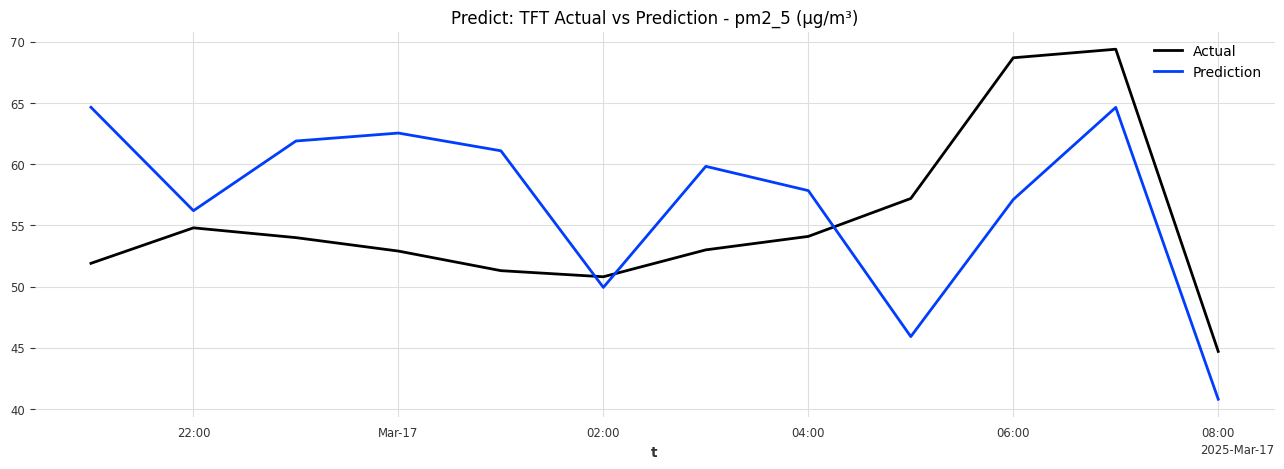

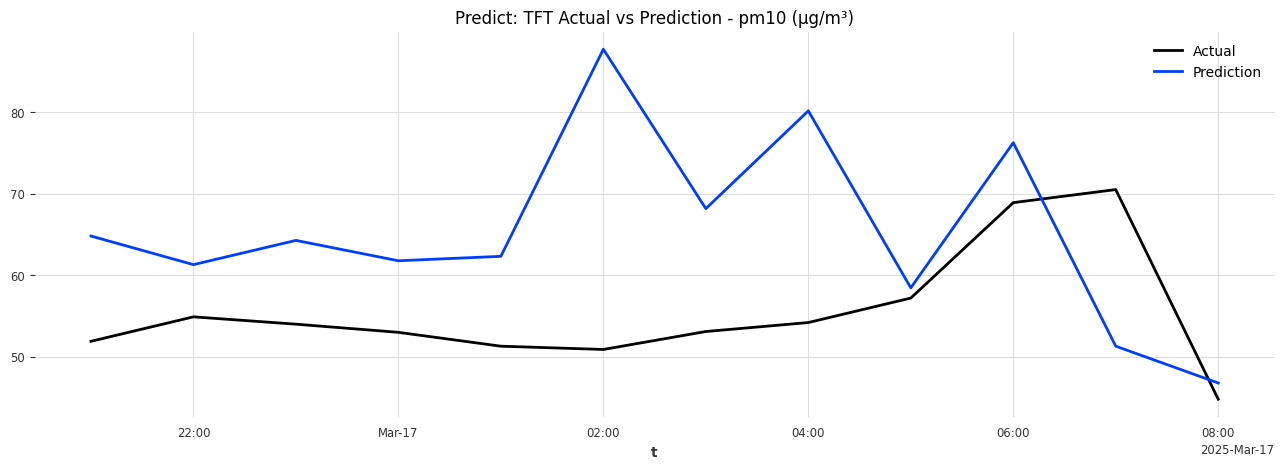

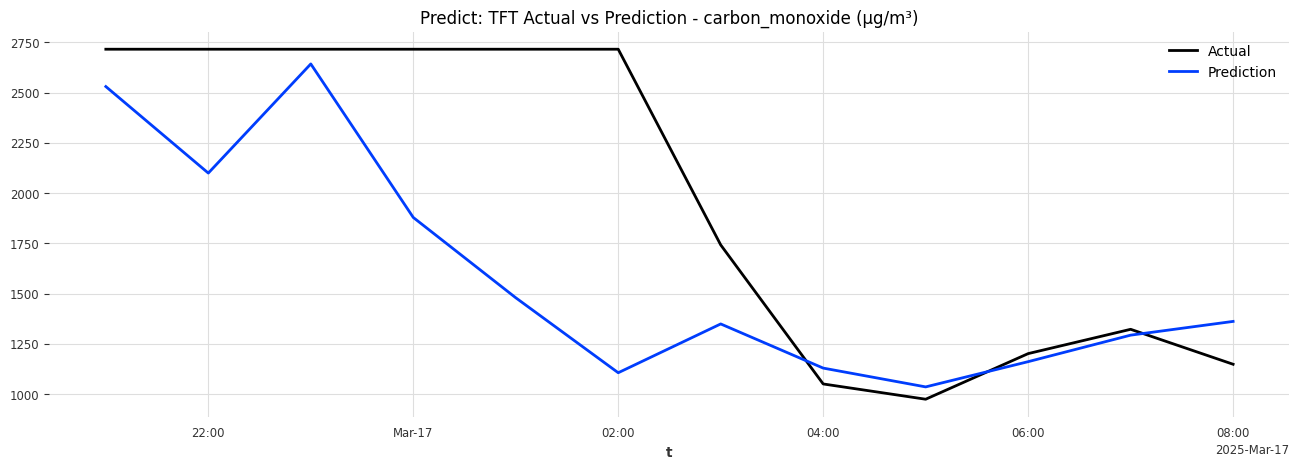

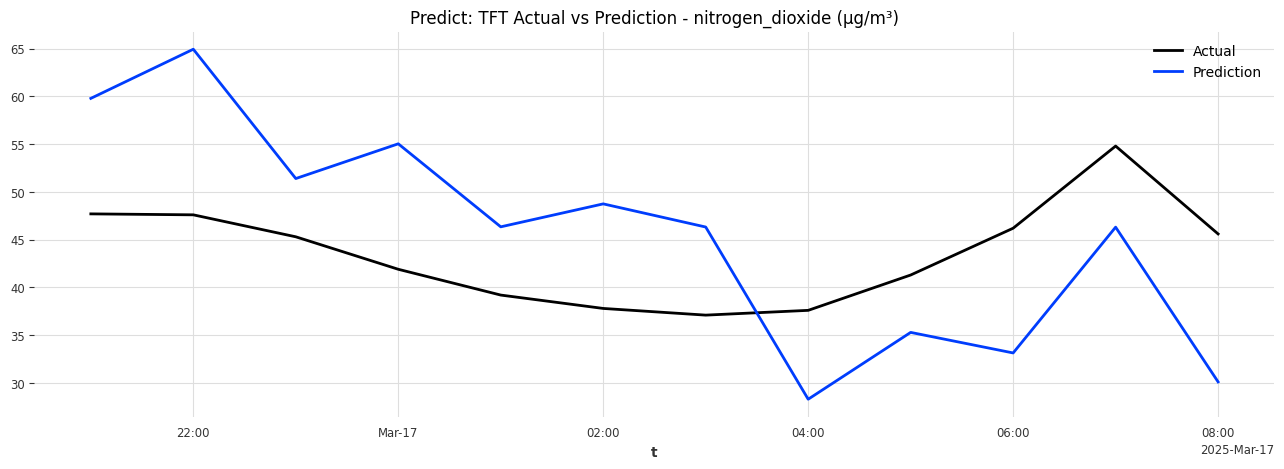

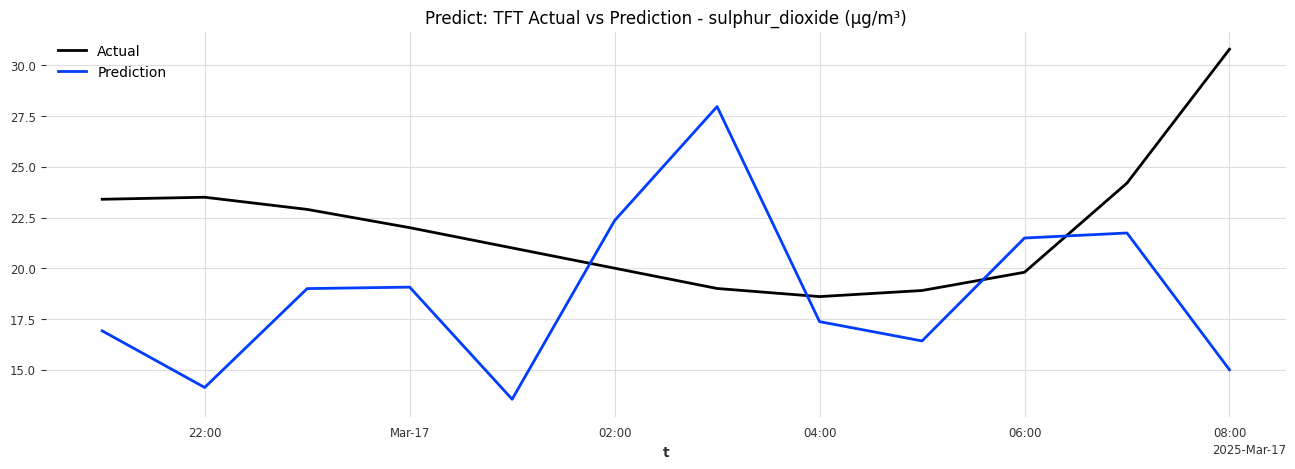

In [18]:
# Line plot for predict
for col in actual_pred.components:
    
    plt.figure(figsize=(16,5))
    
    actual_pred[col].plot(label="Actual")
    predict[col].plot(label="Prediction")
    
    plt.title(f"Predict: TFT Actual vs Prediction - {col_decode[col]}")
    plt.legend()
    plt.savefig(f"../reports/figures/tft/predict_{col}.png", dpi=300)
    plt.show()

## Line Plot for Backtesting

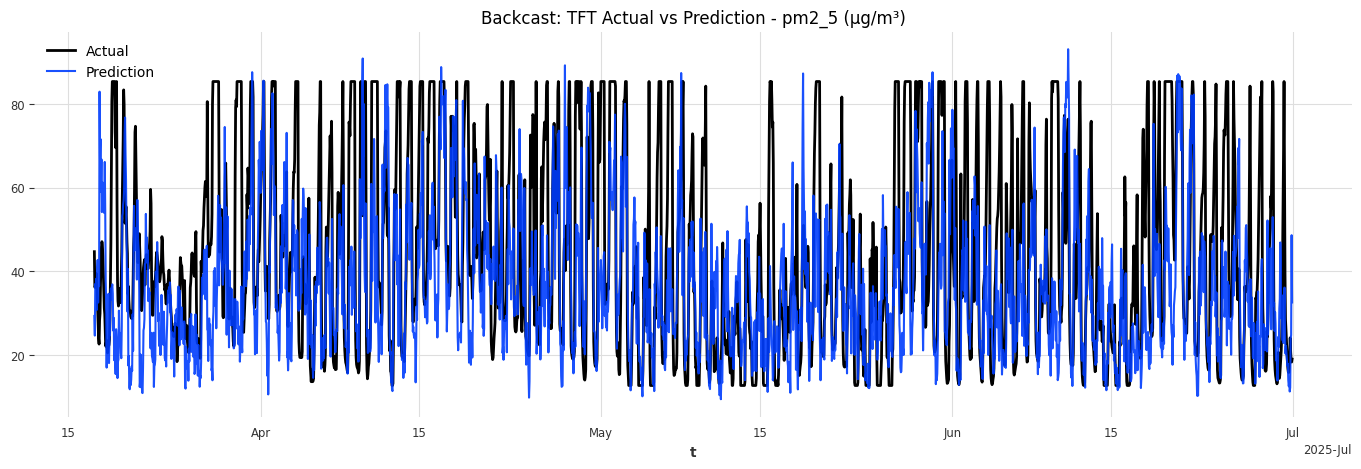

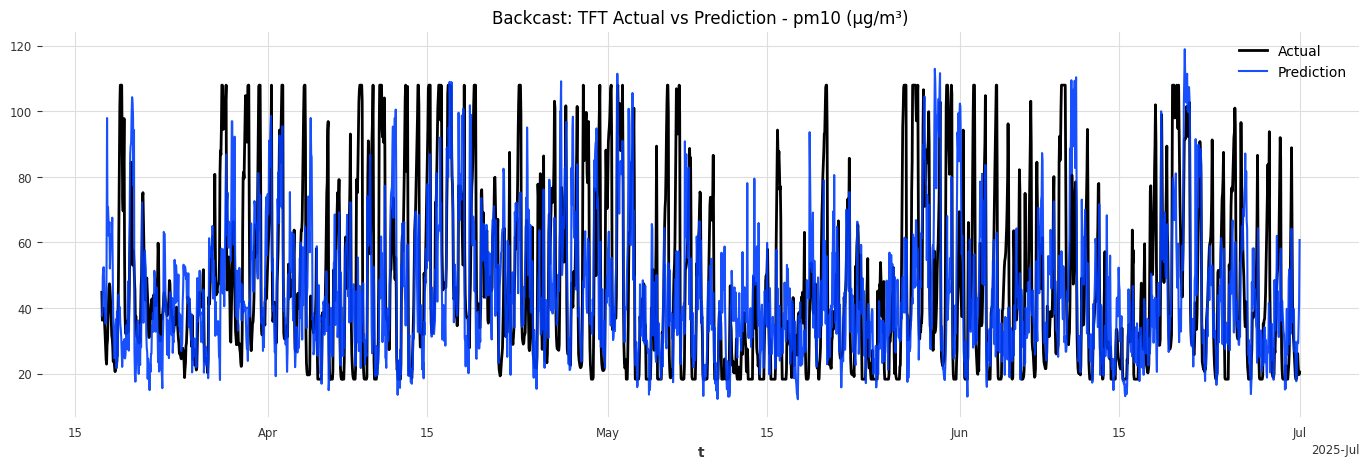

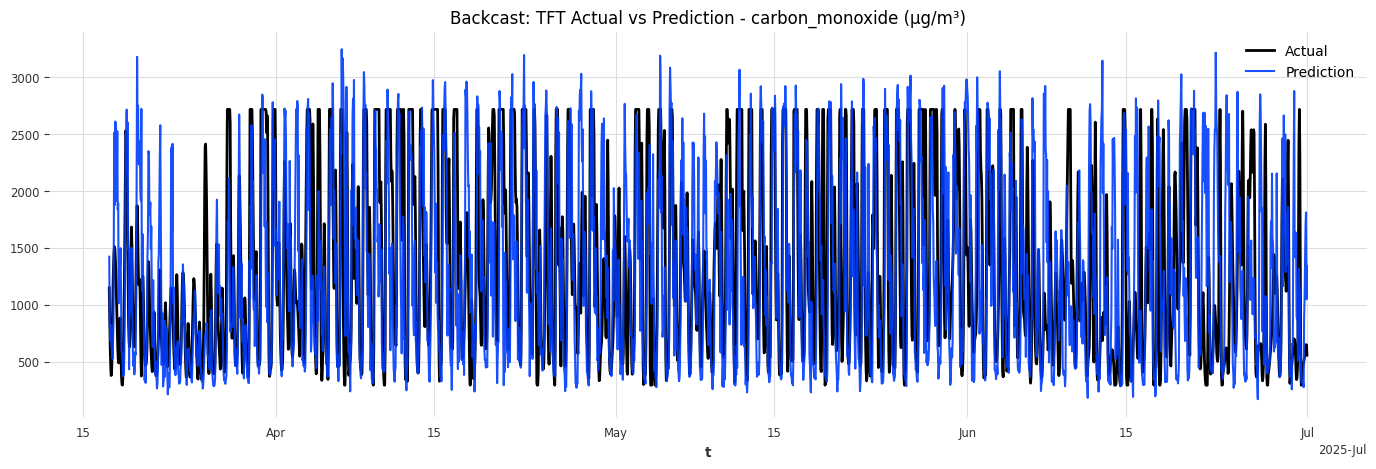

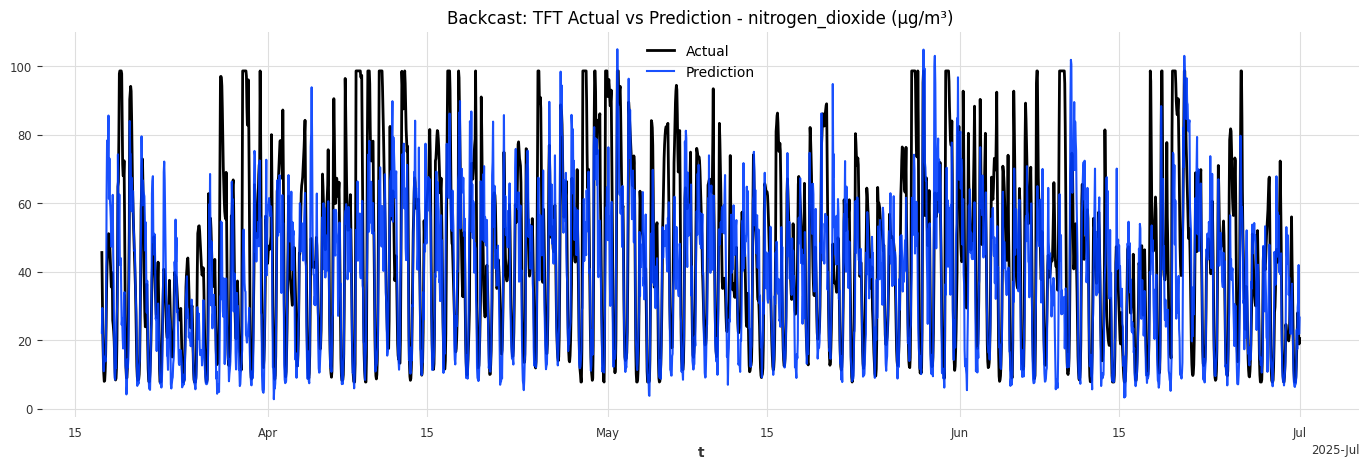

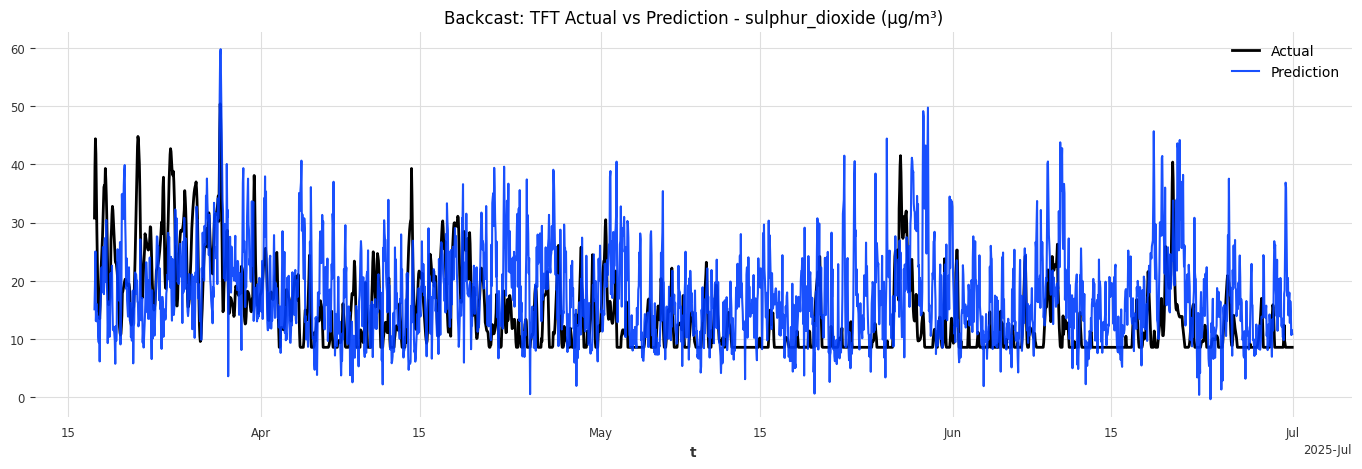

In [19]:
# Line plot for predict
for col in actual_backcast.components:
    
    plt.figure(figsize=(17,5))
    
    actual_backcast[col].plot(label="Actual", linewidth=2, alpha=1)
    backcast[col].plot(label="Prediction", linewidth=1.5, alpha=0.9)
    
    plt.title(f"Backcast: TFT Actual vs Prediction - {col_decode[col]}")
    plt.legend()
    plt.savefig(f'../reports/figures/tft/backcast{col}.png', dpi=300)
    plt.show()

## Explainer

In [20]:
future_for_explain = X_future.append(X_future_more_ts)

# create the explainer and generate explanations
explainer = TFTExplainer(model)
results = explainer.explain(
    foreground_series=Y,
    foreground_past_covariates=X_past,
    foreground_future_covariates=future_for_explain
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 73.83it/s]


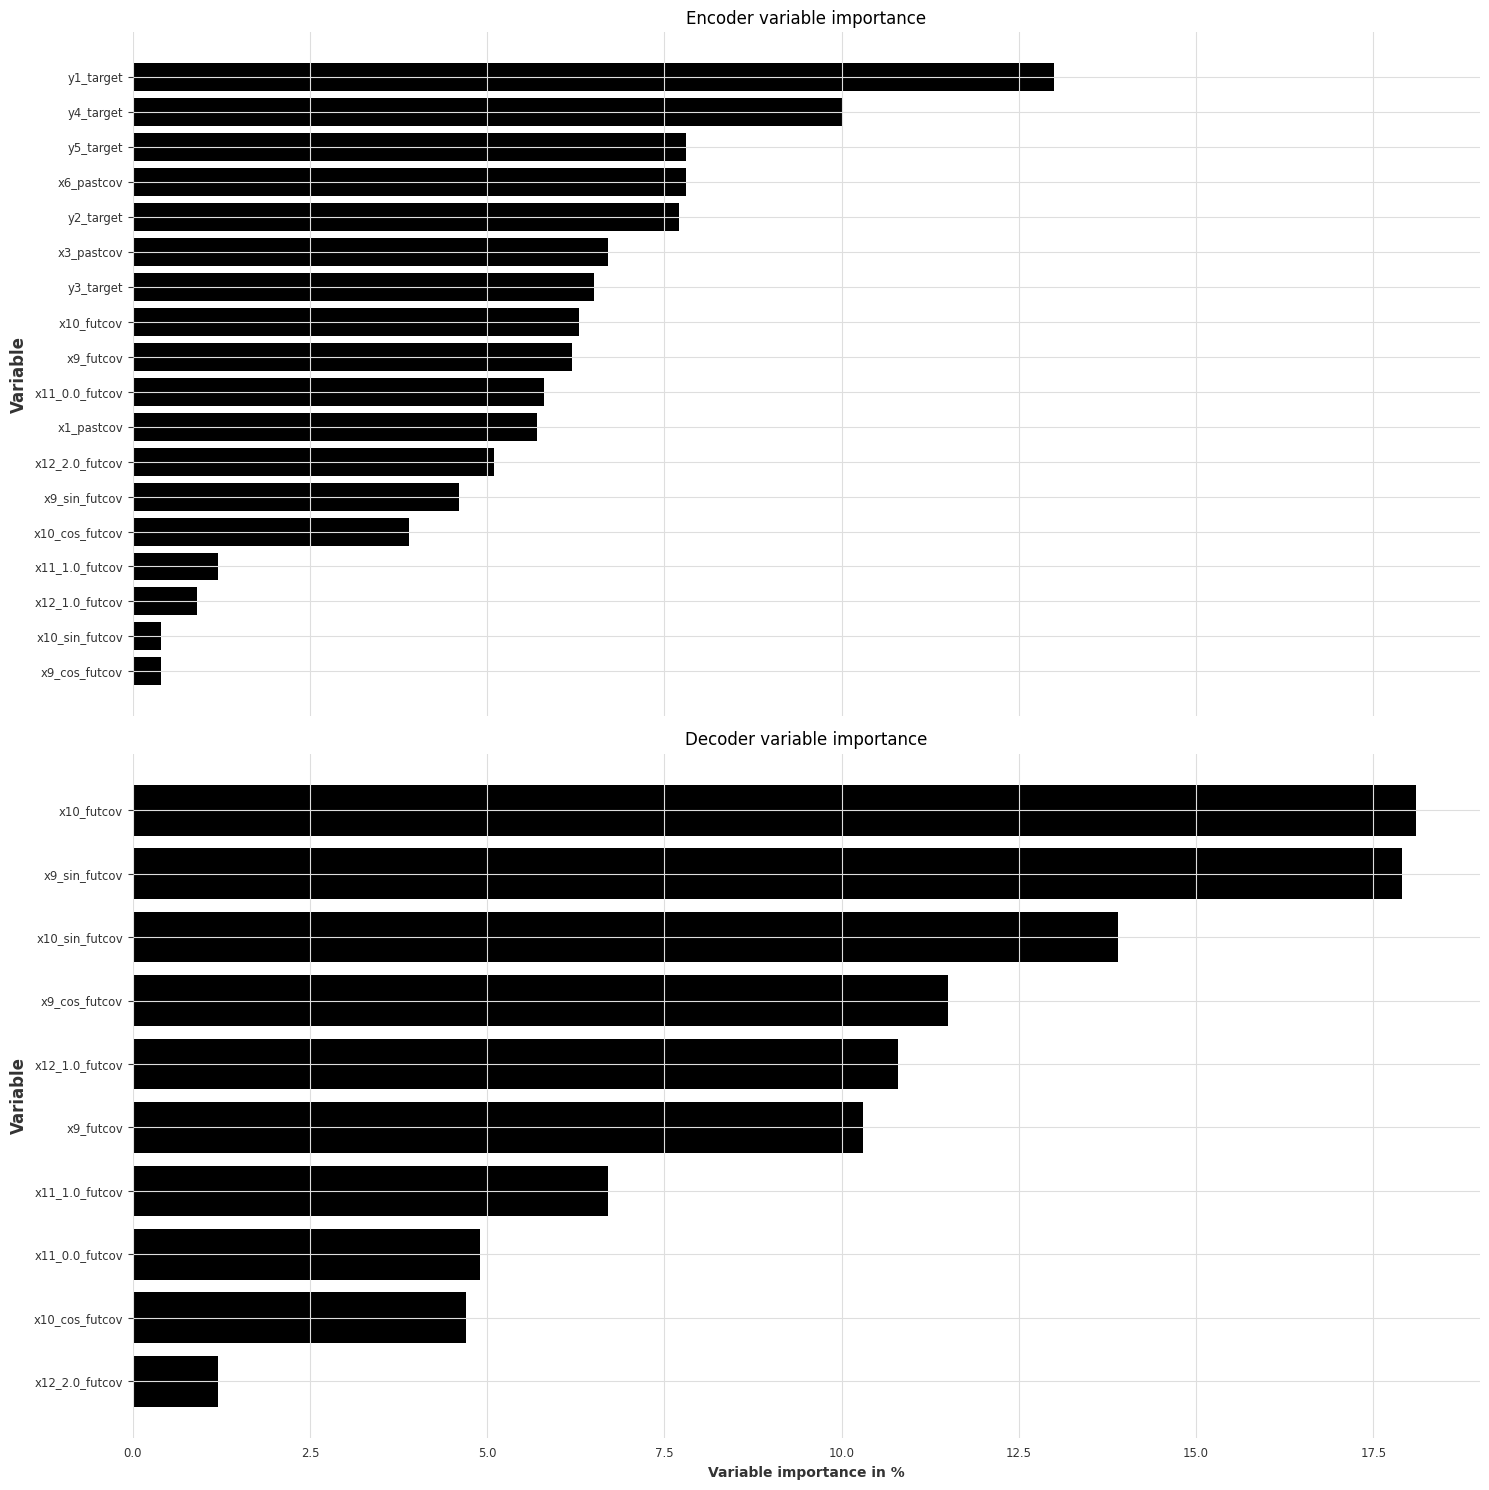

<Figure size 640x480 with 0 Axes>

In [21]:
# Plotting the variabel importance
explainer.plot_variable_selection(results, fig_size = (15, 15))
plt.savefig('../reports/figures/tft/variables_importance.png', dpi=300)

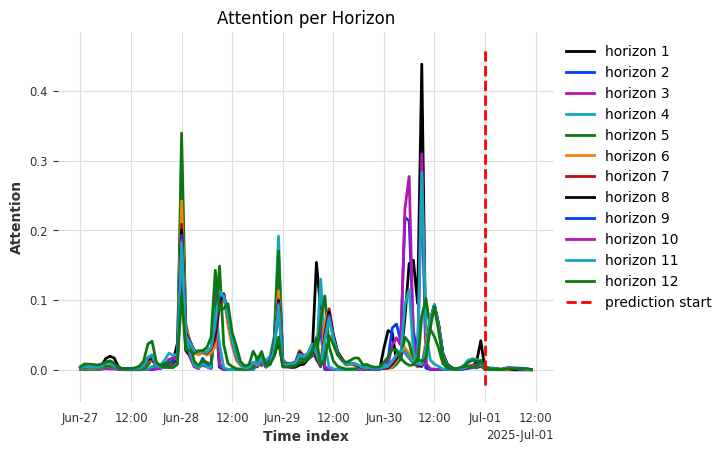

<Figure size 640x480 with 0 Axes>

In [22]:
# Attention mechanism 1
explainer.plot_attention(results, plot_type = 'all', show_index_as='time')
plt.savefig('../reports/figures/tft/attention_all.png', dpi=300)

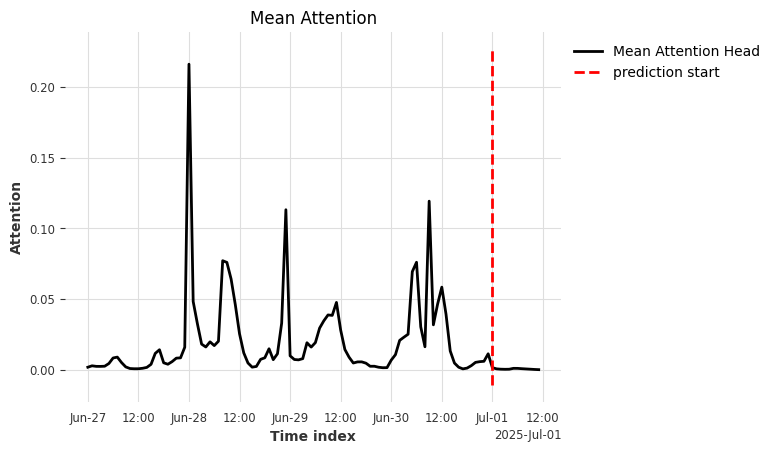

<Figure size 640x480 with 0 Axes>

In [23]:
# Attention mechanism 2
explainer.plot_attention(results, plot_type = 'time', show_index_as='time')
plt.savefig('../reports/figures/tft/attention_time.png', dpi=300)

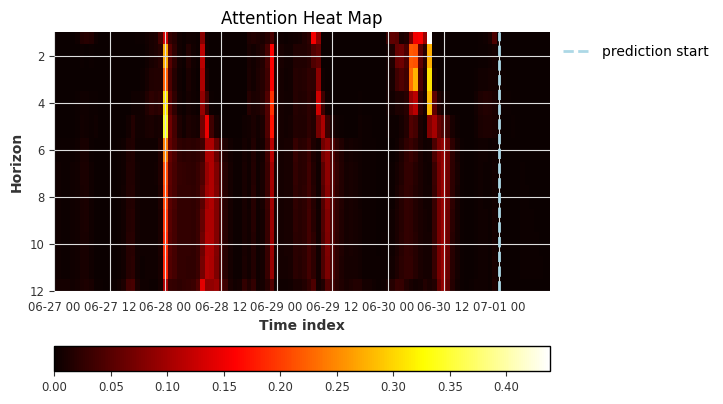

<Figure size 640x480 with 0 Axes>

In [24]:
# Attention mechanism 3
explainer.plot_attention(results, plot_type = 'heatmap', show_index_as='time')
plt.savefig('../reports/figures/tft/attention_heatmap.png', dpi=300)

# Predict the Future

In [29]:
predict_start = time.time()
forecasts_future = model.predict(
    n                 = output_chunk_length,
    series            = Y,
    past_covariates   = X_past,
    future_covariates = X_future.append(X_future_more_ts),
    verbose           = False,
    n_jobs            = 1,
    random_state      = random_state,
)
predict_cost_seconds = time.time() - predict_start

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [30]:
# Inverse scaling & prenorm transform per target
pred_future = Y_scaler.inverse_transform(forecasts_future)

if prenorm_type is None:
    pass
elif prenorm_type == 'sqrt':
    pred_future = pred_future ** 2
elif prenorm_type == 'log1p':
    pred_future = pred_future.map(np.expm1)

In [31]:
# Save prediction on excel
pred_future_df = pred_future.to_dataframe()
pred_future_df.columns = [f"{c}_future_pred" for c in pred_future_df.columns]

# Save to excel
pred_future_df.to_excel('../reports/tft_future_prediction_results.xlsx')

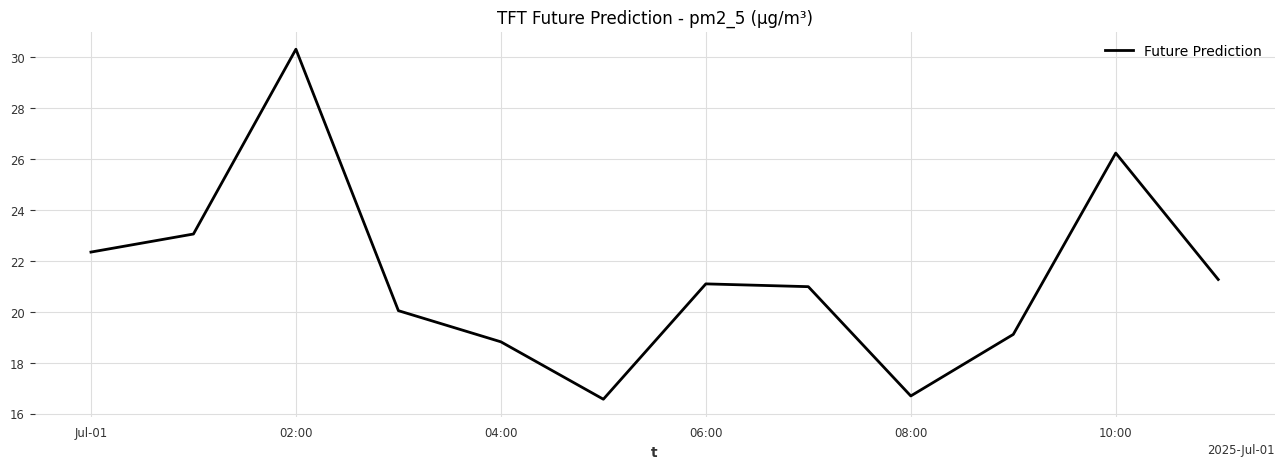

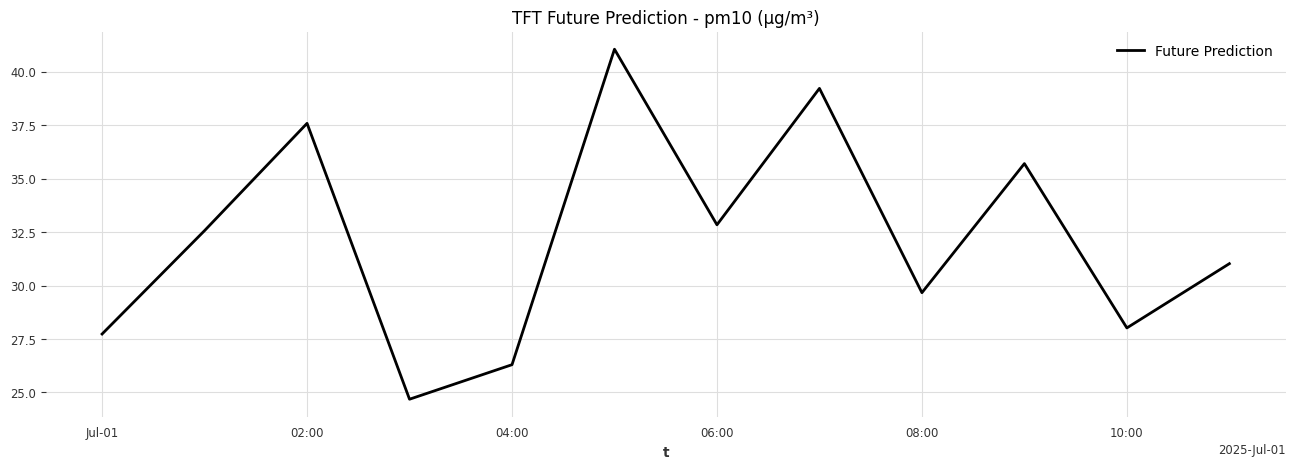

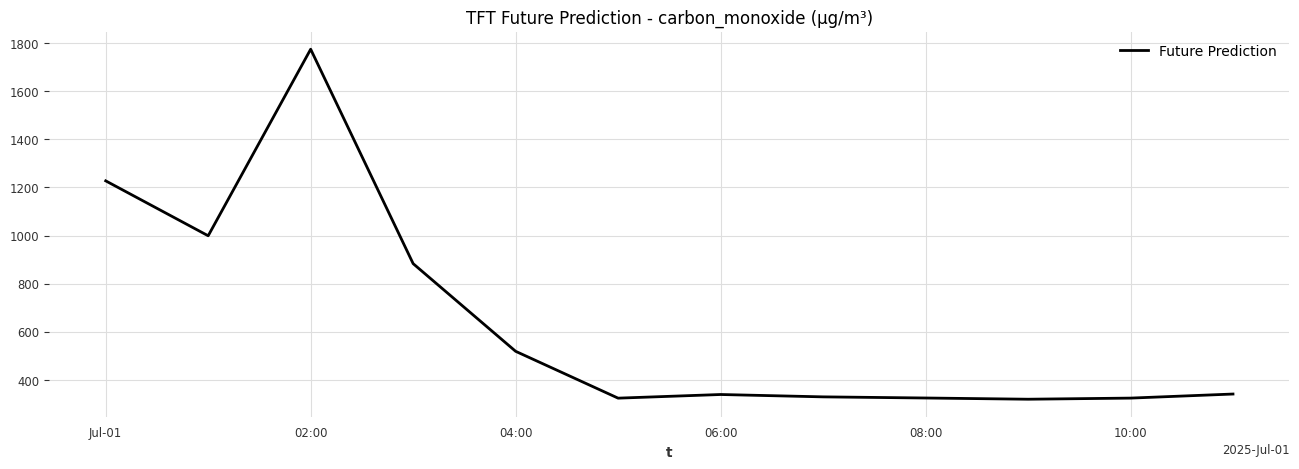

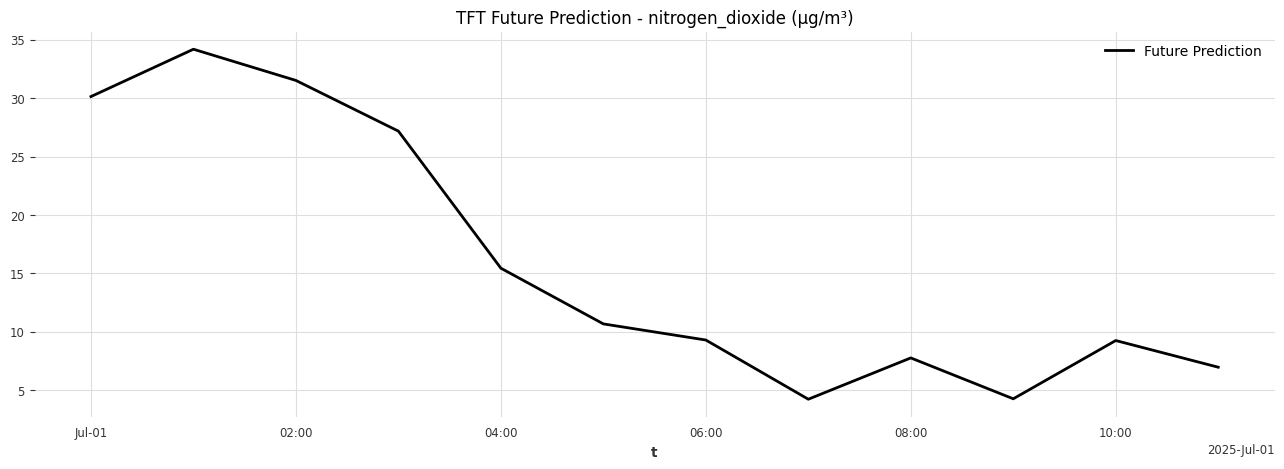

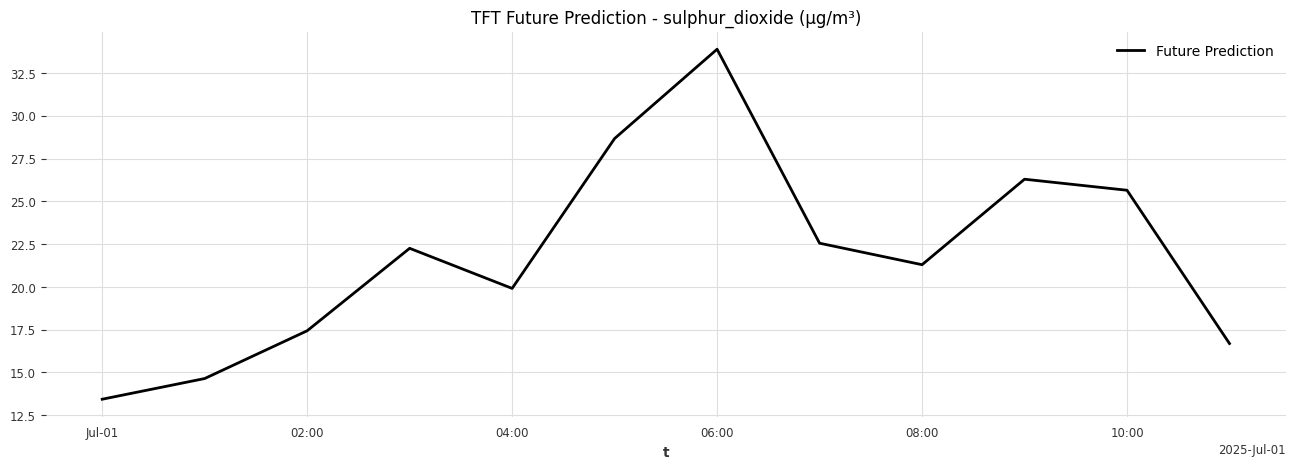

In [33]:
# Line plot for predict
for col in actual_pred.components:
    
    plt.figure(figsize=(16,5))
    pred_future[col].plot(label="Future Prediction")
    
    plt.title(f"TFT Future Prediction - {col_decode[col]}")
    plt.legend()
    plt.savefig(f'../reports/figures/tft/future_predict_{col}.png', dpi=300)
    plt.show()